Gate 2

# Plain-language analysis contract

---



**Associated dataset:** data/allstate_claims_data.csv

In [ ]:
#Imports
from google.colab import drive
import pandas as pd
import numpy as np
import os


In [ ]:
#Connect this notebook to Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load the dataset
df = pd.read_csv("/content/drive/MyDrive/allstate_claims_data.csv")

In [ ]:
#Calculating the MAE
df.head()
medianloss = df["loss"].median()
MAE = sum(abs(df["loss"] - medianloss))/len(df["loss"])
print(f"Baseline MAE is: {MAE}")


Baseline MAE is: 1809.0487864675708


In [ ]:
df.isnull().sum()
df.describe()

,id,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
count,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000
mean,294135.982561,0.493861,0.507188,0.498918,0.491812,0.487428,0.490945,0.484970,0.486437,0.485506,0.498066,0.493511,0.493150,0.493138,0.495717,3037.337686
std,169336.084867,0.187640,0.207202,0.202105,0.211292,0.209027,0.205273,0.178450,0.199370,0.181660,0.185877,0.209737,0.209427,0.212777,0.222488,2904.086186
min,1.000000,0.000016,0.001149,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.179722,0.670000
25%,147748.250000,0.346090,0.358319,0.336963,0.327354,0.281143,0.336105,0.350175,0.312800,0.358970,0.364580,0.310961,0.311661,0.315758,0.294610,1204.460000
50%,294539.500000,0.475784,0.555782,0.527991,0.452887,0.422268,0.440945,0.438285,0.441060,0.441450,0.461190,0.457203,0.462286,0.363547,0.407403,2115.570000
75%,440680.500000,0.623912,0.681761,0.634224,0.652072,0.643315,0.655021,0.591045,0.623580,0.566820,0.614590,0.678924,0.675759,0.689974,0.724623,3864.045000
max,587633.000000,0.984975,0.862654,0.944251,0.954297,0.983674,0.997162,1.000000,0.980200,0.995400,0.994980,0.998742,0.998484,0.988494,0.844848,121012.250000


One possible limitation could be that annoymized variables are defined as cont1, cont2, etc, so it may be hard to interpret what they are.

# Project-specific data dictionary

---





In [ ]:
#Create a dictionary documenting the metadata, specific roles, and lineage of all fields, while leaving unknown meanings unresolved.
data_dictionary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})
data_dictionary

,Data Type,Missing Values,Unique Values
id,int64,0,188318
cat1,object,0,2
cat2,object,0,2
cat3,object,0,2
cat4,object,0,2
...,...,...,...
cont11,float64,0,326
cont12,float64,0,328
cont13,float64,0,353
cont14,float64,0,18740


Lineage:
Historical auto insurance claims database provided by Allstate.

*   id is the unique idenfier
*   cat1-cat116 are the annoymized categorical features
*   cont1 - cont14 are the annoymized continous features
*   loss is the target variable






# Target-analysis method

---

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Statistical Summary of loss
print("Statistical Summary of Target Variable (loss)")
display(df['loss'].describe())


Statistical Summary of Target Variable (loss)


,loss
count,188318.000000
mean,3037.337686
std,2904.086186
min,0.670000
25%,1204.460000
50%,2115.570000
75%,3864.045000
max,121012.250000


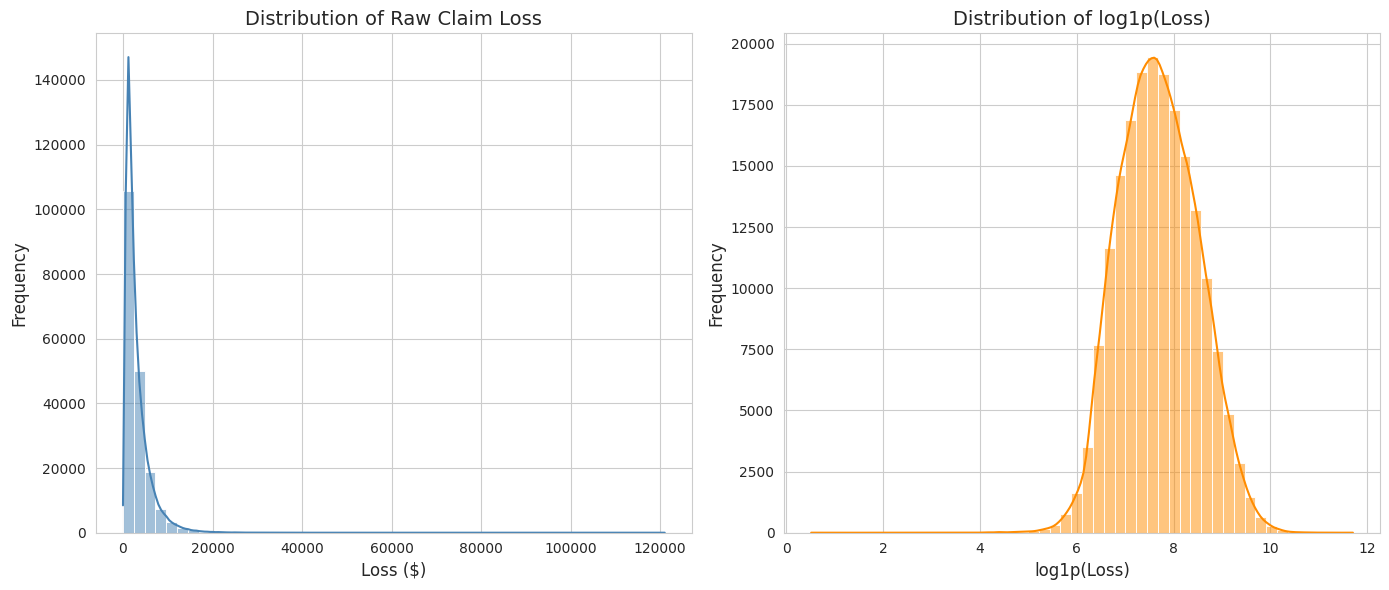

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plots the actual loss
sns.histplot(df['loss'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Raw Claim Loss', fontsize=14)
axes[0].set_xlabel('Loss ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
#plots the log1p(loss)
sns.histplot(np.log1p(df['loss']), bins=50, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Distribution of log1p(Loss)', fontsize=14)
axes[1].set_xlabel('log1p(Loss)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()


# Categorical-analysis method

---

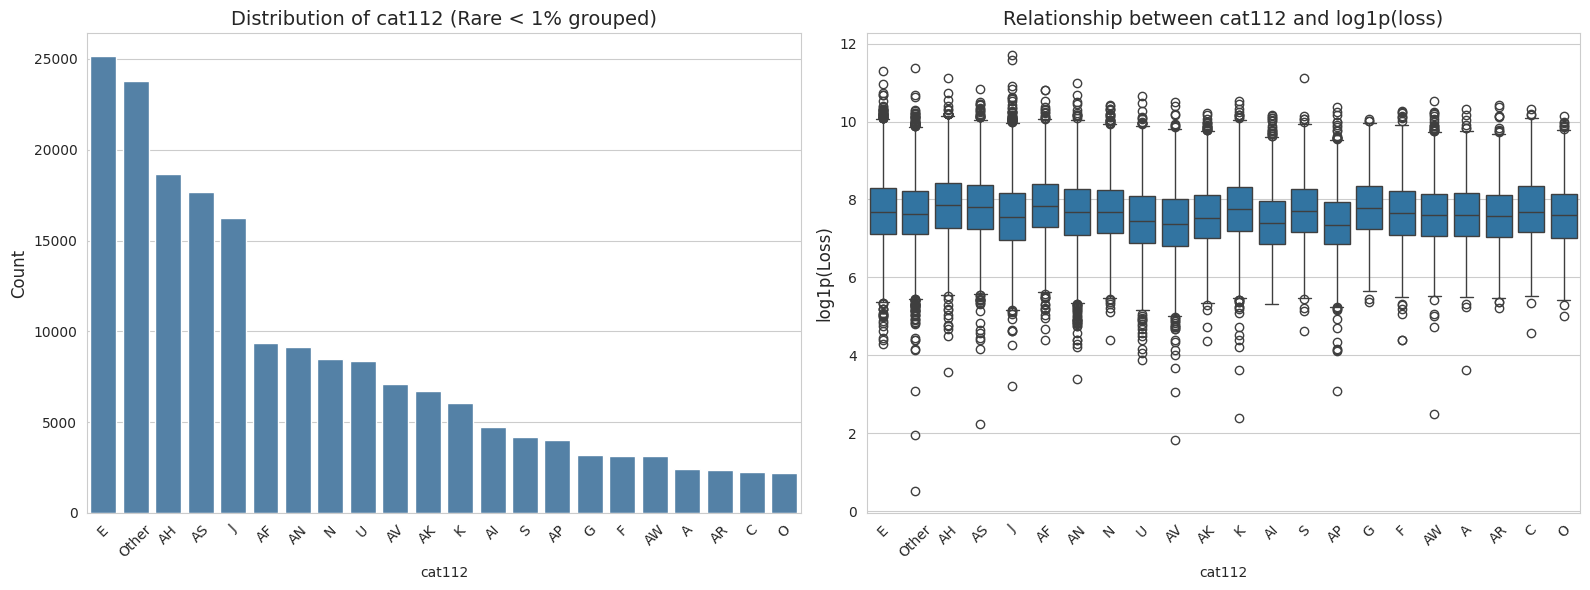

In [ ]:
#using the 112th categorical variable
cat_col = 'cat112'
#1 % threshold
threshold = 0.01

# 1. Apply rare-level threshold
# Get the percentage of how often each category appears
frequencies = df[cat_col].value_counts(normalize=True)

# Find categories below the 1% threshold
rare_categories = frequencies[frequencies < threshold].index

# Creates a copy of the dataframe for plotting
plot_data = df.copy()
plot_data[cat_col] = plot_data[cat_col].replace(rare_categories, 'Other')
plot_data['log_loss'] = np.log1p(plot_data['loss'])

# Set up plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")
#sort bars
order = plot_data[cat_col].value_counts().index

# Plot A: Categorical Distribution (Countplot)
sns.countplot(data=plot_data, x=cat_col, order=order, color='steelblue', ax=axes[0])
axes[0].set_title(f'Distribution of {cat_col} (Rare < 1% grouped)', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot B: Target Relationship (Boxplot)
sns.boxplot(data=plot_data, x=cat_col, y='log_loss', order=order, ax=axes[1])
axes[1].set_title(f'Relationship between {cat_col} and log1p(loss)', fontsize=14)
axes[1].set_ylabel('log1p(Loss)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Continuous-analysis method

---

Statistical Summary of Continuous Features


,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14
count,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000
mean,0.493861,0.507188,0.498918,0.491812,0.487428,0.490945,0.484970,0.486437,0.485506,0.498066,0.493511,0.493150,0.493138,0.495717
std,0.187640,0.207202,0.202105,0.211292,0.209027,0.205273,0.178450,0.199370,0.181660,0.185877,0.209737,0.209427,0.212777,0.222488
min,0.000016,0.001149,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.179722
25%,0.346090,0.358319,0.336963,0.327354,0.281143,0.336105,0.350175,0.312800,0.358970,0.364580,0.310961,0.311661,0.315758,0.294610
50%,0.475784,0.555782,0.527991,0.452887,0.422268,0.440945,0.438285,0.441060,0.441450,0.461190,0.457203,0.462286,0.363547,0.407403
75%,0.623912,0.681761,0.634224,0.652072,0.643315,0.655021,0.591045,0.623580,0.566820,0.614590,0.678924,0.675759,0.689974,0.724623
max,0.984975,0.862654,0.944251,0.954297,0.983674,0.997162,1.000000,0.980200,0.995400,0.994980,0.998742,0.998484,0.988494,0.844848


Correlation Matrix of the continous features


,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
cont1,1.000000,-0.085180,-0.445431,0.367549,-0.025230,0.758315,0.367384,0.361163,0.929912,0.808551,0.596090,0.614225,0.534850,0.056688,-0.010237
cont2,-0.085180,1.000000,0.455861,0.038693,0.191427,0.015864,0.048187,0.137468,-0.032729,0.063526,0.116824,0.106250,0.023335,-0.045584,0.141528
cont3,-0.445431,0.455861,1.000000,-0.341633,0.089417,-0.349278,0.097516,-0.185432,-0.417054,-0.325562,0.025271,0.006111,-0.418203,-0.039592,0.111053
cont4,0.367549,0.038693,-0.341633,1.000000,0.163748,0.220932,-0.115064,0.528740,0.328961,0.283294,0.120927,0.130453,0.179342,0.017445,-0.035831
cont5,-0.025230,0.191427,0.089417,0.163748,1.000000,-0.149810,-0.249344,0.009015,-0.088202,-0.064967,-0.151548,-0.148217,-0.082915,-0.021638,-0.011355
cont6,0.758315,0.015864,-0.349278,0.220932,-0.149810,1.000000,0.658918,0.437437,0.797544,0.883351,0.773745,0.785144,0.815091,0.042178,0.040967
cont7,0.367384,0.048187,0.097516,-0.115064,-0.249344,0.658918,1.000000,0.142042,0.384343,0.492621,0.747108,0.742712,0.288395,0.022286,0.119799
cont8,0.361163,0.137468,-0.185432,0.528740,0.009015,0.437437,0.142042,1.000000,0.452658,0.336588,0.302381,0.315904,0.476402,0.043539,0.030508
cont9,0.929912,-0.032729,-0.417054,0.328961,-0.088202,0.797544,0.384343,0.452658,1.000000,0.785697,0.608000,0.626656,0.642028,0.074154,0.014456
cont10,0.808551,0.063526,-0.325562,0.283294,-0.064967,0.883351,0.492621,0.336588,0.785697,1.000000,0.702896,0.713812,0.707876,0.041808,0.020236


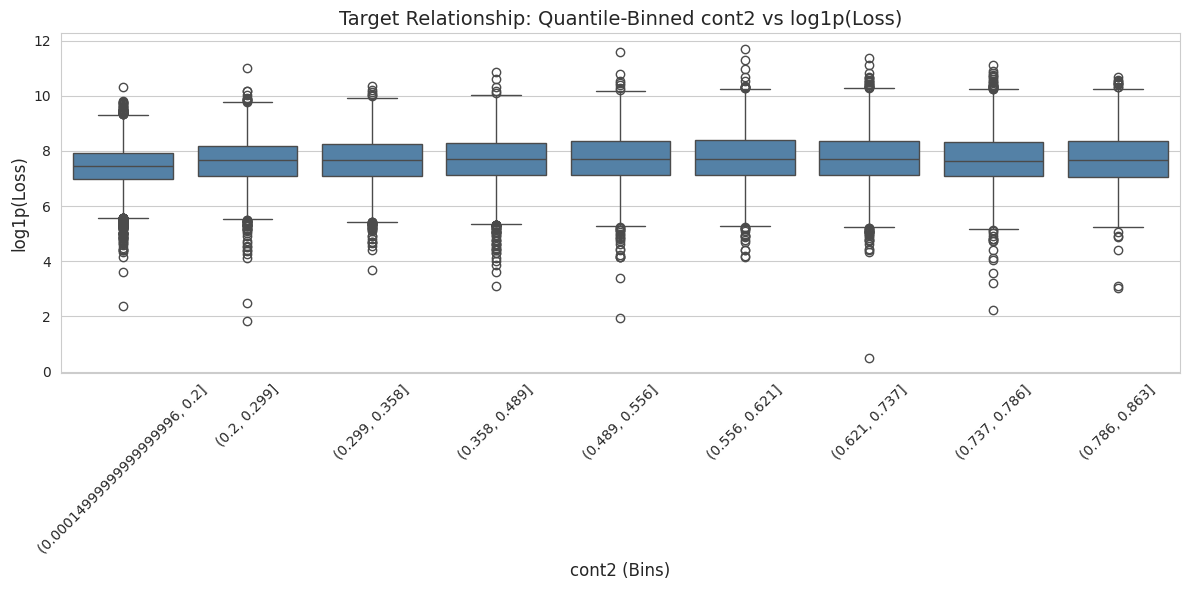

In [ ]:
cont_cols = [col for col in df.columns if col.startswith('cont')]

#Summarizing the continuous field distributions
print("Statistical Summary of Continuous Features")
display(df[cont_cols].describe())

#Correlation matrix
corr_matrix = df[cont_cols + ['loss']].corr()

print("Correlation Matrix of the continous features")
display(corr_matrix)


# Evaluate Quantile-Binned Target Relationships
# Using one feature as an example (cont2) and break it into 10 equal buckets
feature_to_bin = 'cont2'
plot_data = df.copy()

# pd.qcut divides the continuous data into 10 equally sized groups based on percentiles
plot_data['binned_feature'] = pd.qcut(plot_data[feature_to_bin], q=10, duplicates='drop')
plot_data['log_loss'] = np.log1p(plot_data['loss'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='binned_feature', y='log_loss', color='steelblue')
plt.title(f'Target Relationship: Quantile-Binned {feature_to_bin} vs log1p(Loss)', fontsize=14)
plt.xlabel(f'{feature_to_bin} (Bins)', fontsize=12)
plt.ylabel('log1p(Loss)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Versioned Findings Register
*   **[METHODOLOGY]**: Established baseline MAE using target median.
*   **[FINDING]**: `loss` is right-skewed; applied `log1p` for visualization.
*   **[METHODOLOGY]**: Grouped <1% categorical variables into 'Other'.
*  **[LIMITATION]**: Calculated continuous predictor correlations and retained all features